# Customer Churn Analysis

This notebook is an exploration of churn behavior for a telecommunications company. The dataset comes from kaggle and includes 7043 rows and 33 columns of data. The goal of this project is to give helpful business insights by identifying areas of high churn and common reasons for customers leaving amongst those groups.

### Business Questions

- What is the overall churn rate for the company?
- Are there geographic areas with disproportionately high churn?
- When do customers leave, and why at that point?

### First look at the data

In this section, I will familiarize myself with the dataset and it's makeup, while determining steps of the cleaning process needed to be completed prior to analysis.

In [4]:
# Packages used throughout notebook

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
# Loading in the data

Telco = pd.read_csv('Telco_customer_churn.csv')

# This ensures all columns are viewable

pd.set_option('display.max_columns', None)

In [6]:
# First peek at the top 5 rows

Telco.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [7]:
# This gives information on the makeup of the dataframe

Telco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [8]:
# This shows unique churn reasons which will be vital for this project

Telco['Churn Reason'].unique()

array(['Competitor made better offer', 'Moved',
       'Competitor had better devices',
       'Competitor offered higher download speeds',
       'Competitor offered more data', 'Price too high',
       'Product dissatisfaction', 'Service dissatisfaction',
       'Lack of self-service on Website', 'Network reliability',
       'Limited range of services',
       'Lack of affordable download/upload speed',
       'Long distance charges', 'Extra data charges', "Don't know",
       'Poor expertise of online support',
       'Poor expertise of phone support', 'Attitude of service provider',
       'Attitude of support person', 'Deceased', nan], dtype=object)

In [9]:
# Look at the current descriptive statistics prior to cleaning 

Telco.describe(include = 'all')

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
count,7043,7043.0,7043,7043,7043,7043.000000,7043,7043.000000,7043.000000,7043,7043,7043,7043,7043.000000,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043,7043.000000,7043.000000,7043.000000,1869
unique,7043,NaN,1,1,1129,NaN,1652,NaN,NaN,2,2,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,6531,2,NaN,NaN,NaN,20
top,3668-QPYBK,NaN,United States,California,Los Angeles,NaN,"33.964131, -118.272783",NaN,NaN,Male,No,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No,NaN,NaN,NaN,Attitude of support person
freq,1,NaN,7043,7043,305,NaN,5,NaN,NaN,3555,5901,3641,5416,NaN,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174,NaN,NaN,NaN,192
mean,NaN,1.0,NaN,NaN,NaN,93521.964646,NaN,36.282441,-119.798880,NaN,NaN,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN,0.265370,58.699418,4400.295755,NaN
std,NaN,0.0,NaN,NaN,NaN,1865.794555,NaN,2.455723,2.157889,NaN,NaN,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN,0.441561,21.525131,1183.057152,NaN
min,NaN,1.0,NaN,NaN,NaN,90001.000000,NaN,32.555828,-124.301372,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN,0.000000,5.000000,2003.000000,NaN
25%,NaN,1.0,NaN,NaN,NaN,92102.000000,NaN,34.030915,-121.815412,NaN,NaN,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN,0.000000,40.000000,3469.000000,NaN
50%,NaN,1.0,NaN,NaN,NaN,93552.000000,NaN,36.391777,-119.730885,NaN,NaN,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN,0.000000,61.000000,4527.000000,NaN
75%,NaN,1.0,NaN,NaN,NaN,95351.000000,NaN,38.224869,-118.043237,NaN,NaN,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN,1.000000,75.000000,5380.500000,NaN


In [10]:
# Making a copy so the original dataframe remains unchanged

df = Telco.copy() 

## Cleaning up the data

Steps to clean up data
- Column name standardization
- Dropping unnecessary/redundant columns
- Ensuring columns are correct data types
- Grouping redundant values within columns

In [12]:
# Column name standardization to camel case

df.columns = (
    df.columns
        .str.strip()
        .str.lower()
        .str.replace(' ','_'))

df.columns

Index(['customerid', 'count', 'country', 'state', 'city', 'zip_code',
       'lat_long', 'latitude', 'longitude', 'gender', 'senior_citizen',
       'partner', 'dependents', 'tenure_months', 'phone_service',
       'multiple_lines', 'internet_service', 'online_security',
       'online_backup', 'device_protection', 'tech_support', 'streaming_tv',
       'streaming_movies', 'contract', 'paperless_billing', 'payment_method',
       'monthly_charges', 'total_charges', 'churn_label', 'churn_value',
       'churn_score', 'cltv', 'churn_reason'],
      dtype='object')

In [13]:
# Dropping columns 

df = df.drop(['lat_long', 'latitude', 'longitude', 'count', 'churn_value', 'churn_score', 
              'cltv','country', 'state'], axis = 1) 
df.columns

Index(['customerid', 'city', 'zip_code', 'gender', 'senior_citizen', 'partner',
       'dependents', 'tenure_months', 'phone_service', 'multiple_lines',
       'internet_service', 'online_security', 'online_backup',
       'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies',
       'contract', 'paperless_billing', 'payment_method', 'monthly_charges',
       'total_charges', 'churn_label', 'churn_reason'],
      dtype='object')

Reasons for dropping columns
- lat_long, latitude, and longitude were droppped because we aren't making a geographical map in this project so there is no need for these columns
- Count and churn_value are redundant because count can be found using the datasets index and churn_value is an encoded version of churn_label
- Country and state are unnecessary because we are only looking at cities in California meaning their values don't change
- churn_score and cltv are values predertimined with a model used prior to me handling this dataset therefore it doesn't provide any value to this project which is focused on analysis

In [15]:
# Changing column data types

# total_charges is listed as an object but should be a float since it is a money value

df['total_charges'] = df['total_charges'].replace(' ', np.nan) # converting empty strings to NAN
df['total_charges'] = df['total_charges'].astype(float) 

In [16]:
# zip_code is int data type when it is an identifier and should be listed as object data type

df['zip_code'] = df['zip_code'].astype(str)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customerid         7043 non-null   object 
 1   city               7043 non-null   object 
 2   zip_code           7043 non-null   object 
 3   gender             7043 non-null   object 
 4   senior_citizen     7043 non-null   object 
 5   partner            7043 non-null   object 
 6   dependents         7043 non-null   object 
 7   tenure_months      7043 non-null   int64  
 8   phone_service      7043 non-null   object 
 9   multiple_lines     7043 non-null   object 
 10  internet_service   7043 non-null   object 
 11  online_security    7043 non-null   object 
 12  online_backup      7043 non-null   object 
 13  device_protection  7043 non-null   object 
 14  tech_support       7043 non-null   object 
 15  streaming_tv       7043 non-null   object 
 16  streaming_movies   7043 

In [18]:
# Cleaning up columns with redundant information

# Standardizing service related columns by collapsing 'No internet/phone service' into 'No' to simplify categorical analysis

df['multiple_lines'] = df['multiple_lines'].replace('No phone service', 'No')
df['online_security'] = df['online_security'].replace('No internet service', 'No')
df['online_backup'] = df['online_backup'].replace('No internet service', 'No')
df['device_protection'] = df['device_protection'].replace('No internet service', 'No')
df['tech_support'] = df['tech_support'].replace('No internet service', 'No')
df['streaming_tv'] = df['streaming_tv'].replace('No internet service', 'No')
df['streaming_movies'] = df['streaming_movies'].replace('No internet service', 'No')

In [19]:
df.describe(include = 'all')

,customerid,city,zip_code,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn_label,churn_reason
count,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043.000000,7032.000000,7043,1869
unique,7043,1129,1652,2,2,2,2,NaN,2,2,3,2,2,2,2,2,2,3,2,4,NaN,NaN,2,20
top,3668-QPYBK,Los Angeles,90003,Male,No,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,NaN,No,Attitude of support person
freq,1,305,5,3555,5901,3641,5416,NaN,6361,4072,3096,5024,4614,4621,4999,4336,4311,3875,4171,2365,NaN,NaN,5174,192
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,2283.300441,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,2266.771362,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,18.800000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,401.450000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,1397.475000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,3794.737500,NaN,NaN


### Target Overview

In [21]:
# Overall Churn rate

df['churn_label'].value_counts(normalize = True) * 100

churn_label
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

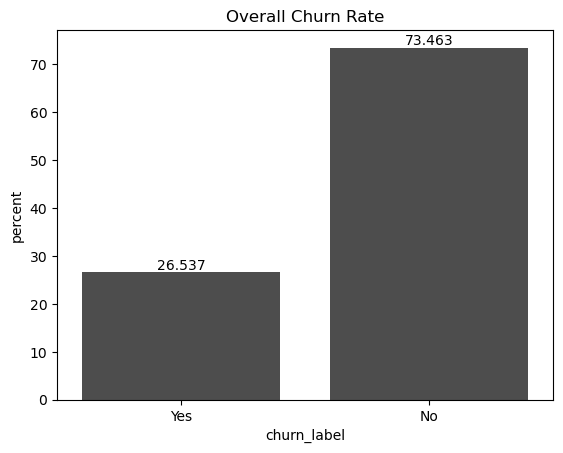

In [22]:
# Seaborn countplot
ax = sns.countplot(
    data = df,
    x = 'churn_label',
    stat = 'percent',
    color = '.3'
)
ax.bar_label(ax.containers[0])
ax.set_title("Overall Churn Rate") 
plt.show()

About 27% of customers are leaving, which is a significant chunk of the customer base. This leads to the need for further inverstigation on what key factors are causing customers to look for other service options.

### EDA City Vs. Churn

- Identifying churn rate by city is a good way to localize areas of concern for the company. This will be accomplished by determining the top ten cities with the highest churn rates.

In [25]:
# First check the amount of customers per city

total_customers = df['city'].value_counts()

total_customers.head(30)

city
Los Angeles         305
San Diego           150
San Jose            112
Sacramento          108
San Francisco       104
Fresno               64
Long Beach           60
Oakland              52
Stockton             44
Bakersfield          40
Glendale             40
Riverside            32
Berkeley             32
Whittier             30
Pasadena             30
Santa Barbara        28
Anaheim              28
San Bernardino       28
Modesto              28
Irvine               28
Santa Monica         25
Torrance             25
Burbank              25
Chula Vista          25
Inglewood            25
Santa Ana            24
Santa Rosa           24
Rancho Cucamonga     20
Escondido            20
Salinas              20
Name: count, dtype: int64

In [26]:
total_customers.describe()

count    1129.000000
mean        6.238264
std        12.254863
min         4.000000
25%         4.000000
50%         4.000000
75%         5.000000
max       305.000000
Name: count, dtype: float64

The total amount of customers per city is highly fragmented. Small sample sizes lead to unreliable results. This is apparent because 7043 customers are spread across 1129 cities and 75% of cities have less than 5 customers. If distributed equally, each city could only have roughly 6 customers. Therefore, a threshold of 20 customers per city will be applied to reduce noise and determine if this strategy is viable.

In [28]:
# Applying threshold

# To filter, the list of total_customers is converted into a data frame
tc_df = pd.DataFrame(total_customers) 

# Applying the threshold and counting the amount of cities that fit the criteria
(tc_df['count'] >= 20).sum()

35

Only 35 of 1129 cities meet the minimum threshold, indicating that city vs churn analysis is unreliable due to extremely small sample sizes. Since the dataset does not include a larger goegraphic grouping, location driven analysis will not be explored further. 

### EDA Tenure Vs. Churn

This section explores how tenure relates to churn behavior. The goal is to identify periods where customers are at the highest risk of leaving. 

This will be accomplished by,
- analyzing distribution of churn across tenure intervals
- calculating churn rate across distinct tenure groups

Further examination into high risk segments, will focus on determining factors associated with churn, giving insight into potential drivers to help direct where retention efforts should be focused.


In [31]:
df['tenure_months'].describe() # Get an statistics summary of the tenure feature
# average tenure time is about 32 months
# 50% of customers stay 29 months or less, so most customers leave within a year and half

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure_months, dtype: float64

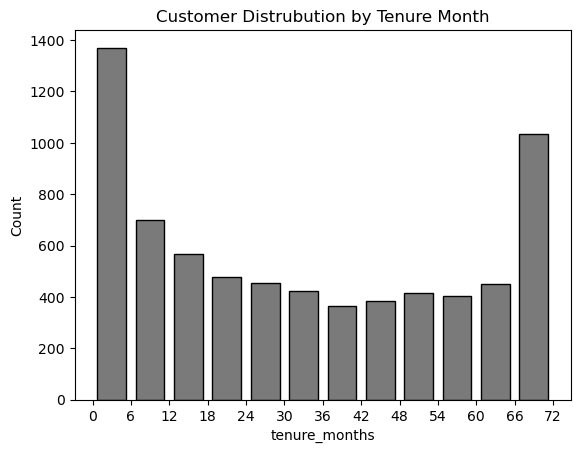

In [82]:
# Histogram
hp = sns.histplot(
    data = df, 
    x = 'tenure_months', 
    binwidth = 6, 
    shrink = .75,
    color = '.3'
)

hp.set_title('Customer Distrubution by Tenure Month')
plt.xticks(np.arange(0, 78, 6))
plt.show()

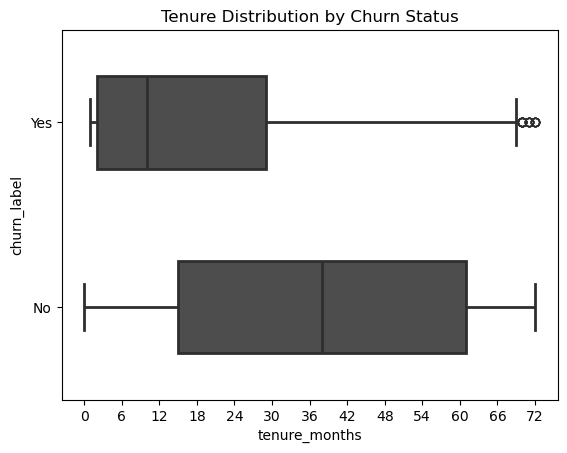

In [96]:
# Boxplot
bp = sns.boxplot(
    data = df,
    x = 'tenure_months',
    y = 'churn_label',
    color = '.3',
    width = .5,
    linewidth = 2
)
bp.set_title('Tenure Distribution by Churn Status')
plt.xticks(np.arange(0, 78, 6))
plt.show()

In [112]:
bins = [0, 6, 12, 24, 36, 48, 60, 72]
labels = ['0-6m','6-12m','12-24m','24-36m','36-48m','48-60m','60-72m']

df['tenure_group'] = pd.cut(df['tenure_months'], bins = bins, labels = labels, include_lowest = True)

In [146]:
df['churn_int'] = (df['churn_label'] == 'Yes').astype(int)

tenure_churn_rate = df.groupby('tenure_group')['churn_int'].mean() * 100

tenure_churn_rate

C:\Users\rodla\AppData\Local\Temp\ipykernel_10640\3914710601.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tenure_churn_rate = df.groupby('tenure_group')['churn_int'].mean() * 100


tenure_group
0-6m      52.937205
6-12m     35.886525
12-24m    28.710938
24-36m    21.634615
36-48m    19.028871
48-60m    14.423077
60-72m     6.609808
Name: churn_int, dtype: float64

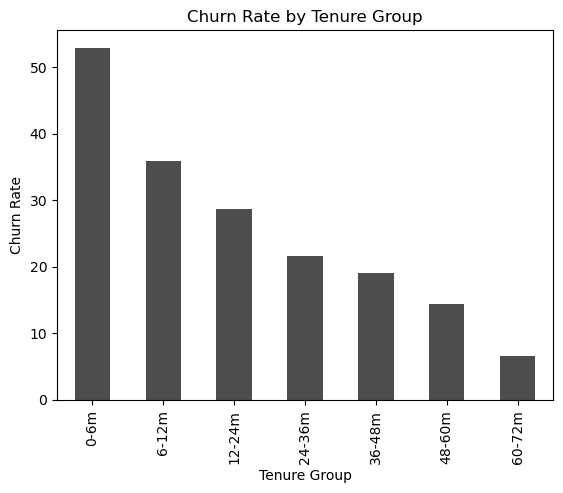

In [151]:
tenure_churn_rate.plot(
    kind = 'bar', 
    color = '.3')
plt.title('Churn Rate by Tenure Group')
plt.ylabel('Churn Rate')
plt.xlabel('Tenure Group')
plt.show()


On average, customer tenure is roughly 32 months, with a median tenure of 29 months. However, summary statistics alone does not depict churn behavior.

Customer distribution by tenure month shows two large groups from 0-6 months and 66-72 months. This indicates a concentration of newer and long-term customers. 

Tenure distribution by churn status illustrates a clear pattern. Customers at the beginning of their lifecycle are at a higher risk of churn. Churn rate analysis reinforces this observation, with customers in their first 6 months having a churn rate of 53%. 

Periods of high risk have been identified through visualizations and aggregated churn metrics. The next step is investigating churn drivers within high risk segments.

#### Common Churn Drivers

In [156]:
common_churn_early = df.loc[df['tenure_months'] <= 6, 'churn_reason'].value_counts()
common_churn_early.head(10)

churn_reason
Attitude of support person                   80
Competitor offered higher download speeds    72
Don't know                                   72
Competitor had better devices                64
Competitor made better offer                 63
Attitude of service provider                 63
Competitor offered more data                 58
Network reliability                          45
Price too high                               41
Product dissatisfaction                      41
Name: count, dtype: int64

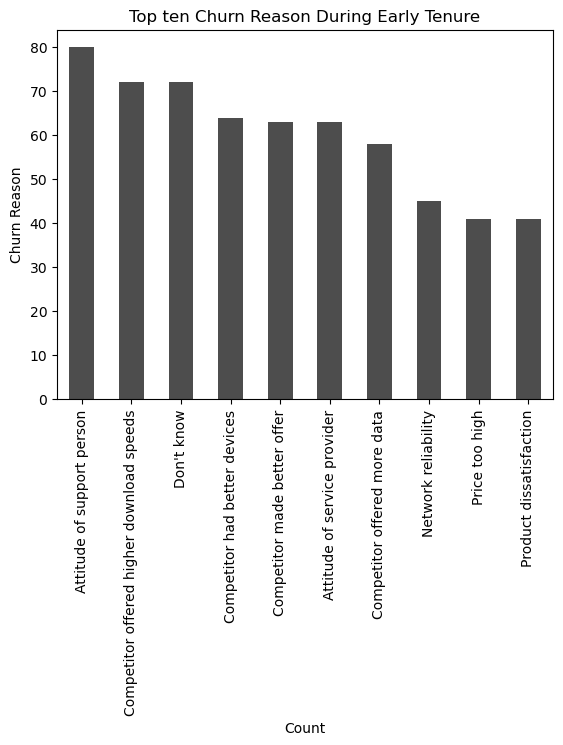

In [162]:
common_churn_early.head(10).plot(
    kind = 'bar',
    color = '.3'
)
plt.title('Top ten Churn Reason During Early Tenure')
plt.ylabel('Churn Reason')
plt.xlabel('Count')
plt.show()

The top 3 churn reasons illustrate an issue with employee personnel and current products being offered. The data shows that there should be a focus on improving customer and employee interactions, especially during initial onboarding. Also, a review of products and services being offered is necessary, in order to stay in the competition. Diving into these to areas gives the best chance of reducing customer churn risk in the early stages of their tenure.

### Conclusion

- Cleaned the date by standardizing column names, dropping unnecessary/redundant columns, ensuring columns are the correct data types, and grouping redundant values within columns.
- Overall churn rate was 27%, indicating that there is a major issue causing customers to leave. The next step was identfying where things are going wrong and why.
- Attempted to analyze the relationship between customers by city and churn. Each cities sample size was to small to continue meaningful exploration. Applying a threshold of 20 customers per city excluded over 90% of the cities in the dataset, stopping this analysis in its path.
- Exploring the relationship between tenure and churn behavior proved more fruitful. Analzing distribution of churn across tenure periods, by way of visualization and aggregated churn metrics, revealed a pattern among customers in the early stages of their lifecycle. Churn risk is at its highest in the first 12 months of tenure. 53% of customers churn between 0-6 months. 
- After identifying this period of high risk, a deeper dive into potential drivers was conducted. Exploration uncovered that the top 3 churn reasons among the tenure group 0-6 months involved issues regarding interactions with employee personel and competitors offering better products and services.
- In conclusion Telco's focus should be on developing employees customer service skills, especially for interacting with newer customers, and improving products and services being offered to beat out the competition. Those key points offer the highest chance of reducing churn rate.
